In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload CSV to notebook 
df = pd.read_csv('Sleep_Efficiency_Updated.csv')
print(df.head())
print(df.info())
print(df.shape)

   ID  Age  Gender           Bedtime       Wakeup time  Sleep duration  \
0   1   65  Female  06/03/2021 01:00  06/03/2021 07:00             6.0   
1   2   69    Male  05/12/2021 02:00  05/12/2021 09:00             7.0   
2   3   40  Female  25/05/2021 21:30  25/05/2021 05:30             8.0   
3   4   40  Female  03/11/2021 02:30  03/11/2021 08:30             6.0   
4   5   57    Male  13/03/2021 01:00  13/03/2021 09:00             8.0   

   Sleep efficiency  REM sleep percentage  Deep sleep percentage  \
0              0.88                    18                     70   
1              0.66                    19                     28   
2              0.89                    20                     70   
3              0.51                    23                     25   
4              0.76                    27                     55   

   Light sleep percentage  Awakenings  Caffeine consumption  \
0                      12         0.0                   0.0   
1                   

In [16]:
df.head(10)

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,06/03/2021 01:00,06/03/2021 07:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,05/12/2021 02:00,05/12/2021 09:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,25/05/2021 21:30,25/05/2021 05:30,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,03/11/2021 02:30,03/11/2021 08:30,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,13/03/2021 01:00,13/03/2021 09:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
5,6,36,Female,01/07/2021 21:00,01/07/2021 04:30,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
6,7,27,Female,21/07/2021 21:00,21/07/2021 03:00,6.0,0.54,28,25,47,2.0,50.0,0.0,Yes,1.0
7,8,53,Male,16/08/2021 00:30,16/08/2021 10:30,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
8,9,41,Female,05/04/2021 02:30,05/04/2021 08:30,6.0,0.79,28,55,17,3.0,50.0,0.0,No,1.0
9,10,11,Female,16/09/2021 01:00,16/09/2021 10:00,9.0,0.55,18,37,45,4.0,0.0,0.0,No,0.0


In [5]:
# Basic stats
print(df.describe())

               ID         Age  Sleep duration  Sleep efficiency  \
count  618.000000  618.000000      618.000000        618.000000   
mean   309.500000   40.344660        7.448220          0.790259   
std    178.545512   13.082805        0.843838          0.133475   
min      1.000000    9.000000        5.000000          0.500000   
25%    155.250000   29.000000        7.000000          0.702500   
50%    309.500000   40.000000        7.500000          0.820000   
75%    463.750000   52.000000        8.000000          0.900000   
max    618.000000   69.000000       10.000000          0.990000   

       REM sleep percentage  Deep sleep percentage  Light sleep percentage  \
count            618.000000             618.000000              618.000000   
mean              22.569579              53.163430               24.266990   
std                3.547206              15.497712               15.106266   
min               15.000000              18.000000                7.000000   
25%   

In [7]:
# Look for any missing values
print(df.isnull().sum())

ID                         0
Age                        0
Gender                     0
Bedtime                    0
Wakeup time                0
Sleep duration             0
Sleep efficiency           0
REM sleep percentage       0
Deep sleep percentage      0
Light sleep percentage     0
Awakenings                27
Caffeine consumption      36
Alcohol consumption       21
Smoking status             0
Exercise frequency         7
dtype: int64


In [17]:
   df['stage_sum'] = df['REM sleep percentage'] + df['Deep sleep percentage'] + df['Light sleep percentage']
   print(df['stage_sum'].describe())

count    618.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: stage_sum, dtype: float64


## Data Dictionary & Feature Interpretation

### Target Variable
- **Sleep efficiency:** Proportion (0–1 scale), mean = 0.79
  - 0.50 = very inefficient (50% of bedtime is actual sleep)
  - 0.99 = nearly perfect efficiency
  - Distribution: appears roughly normal, slightly left-skewed

### Physiological/Sleep Architecture Features
**Note:** These are NOT used as model inputs (see Research Question 
below) — they are only knowable *after* sleep occurs, which would 
violate our deployment constraint. Documented here for completeness 
and EDA purposes only.
- **REM sleep %:** Mean 22.6%, range 15–30%
- **Deep sleep %:** Mean 53.2%, range 18–75%
- **Light sleep %:** Mean 24.3%, range 7–63%
- **Sum check:** REM + Deep + Light = ~100% ✓

### Behavioral Features
- **Caffeine consumption:** mg/day
  - Range: 0–200mg
  - Mean: 24.5mg
  - Interpretation: Likely measured from food/drink diary
  - Missing: 36 values (5.8%)
  
- **Alcohol consumption:** Discrete scale (0–5 drinks/week)
  - All integer values
  - Mean: 1.11 drinks/week
  - Missing: 21 values (3.4%)
  
- **Exercise frequency:** Times per week
  - Range: 0–5x/week
  - Mean: 1.79x/week
  - Missing: 7 values (1.1%)

### Demographic Features
- **Age:** Range 9–69, mean 40.3 years
- **Gender:** Male/Female

### Temporal Features
- **Bedtime & Wakeup time:** Full datetime strings (need parsing)
  - Will extract hour of day (0–23) as feature
  - Date doesn't matter, only time of day affects sleep
  
- **Sleep duration:** Already calculated (hours)
  - Range: 5–10 hours
  - Mean: 7.45 hours

### Data Quality Notes
- 1 row missing (619 → 618)
- Awakenings: 27 missing (4.4%)
- Caffeine: 36 missing (5.8%)
- Alcohol: 21 missing (3.4%)
- Exercise: 7 missing (1.1%)
- **Handling:** Will drop rows with missing values or impute with median

## Research Question

### Problem Statement
Predict sleep efficiency (0–1) directly from lifestyle, behavioral, 
and demographic inputs a person knows *before* they sleep — so 
predictions are usable for "what if I changed X" experimentation 
(e.g., "if I move my bedtime earlier or cut caffeine, how much 
might my efficiency improve?").

### Deployment Constraint (critical)
At prediction time, a user has NOT yet slept. They only know:
- Their demographics (age, gender)
- Planned bedtime/wake time
- Today's behavior (caffeine, alcohol, smoking, exercise)

They do NOT know (yet): REM%, Deep%, Light%, Awakenings — these 
are measured DURING/AFTER sleep and cannot be used as model inputs 
without breaking the use case.

### Input (deployment-safe)
Age, Gender, Bedtime, Wakeup time, Sleep duration, Caffeine 
consumption, Alcohol consumption, Smoking status, Exercise frequency

### Excluded (data leakage)
REM sleep %, Deep sleep %, Light sleep %, Awakenings — only knowable 
after sleep occurs

### Output
Predicted Sleep efficiency (continuous, 0–1)

### Evaluation Metric
MAE (Mean Absolute Error) — average absolute error in efficiency 
points. Chosen for interpretability: an MAE of 0.05 means predictions 
are off by ~5 percentage points on average.

### Why This Matters
Sleep efficiency is a proxy for sleep quality, but duration alone 
doesn't capture the full picture. A 2021 study of 82 university 
athletes found sleep quality had a stronger protective association 
with reduced injury/illness risk (Odds Ratio 0.6) than sleep 
duration alone (Odds Ratio 0.8) (Hamlin et al., 2021). This suggests 
quality-focused metrics like efficiency carry real predictive value 
beyond just tracking hours slept.

Note: that study measured subjective self-rated sleep quality 
(5-point scale), not sleep efficiency % specifically — a related 
but distinct measure. We treat this as supporting evidence for why 
quality matters, not a direct validation of the efficiency metric 
itself.

**Source:** Hamlin, M.J., et al. (2021). The Effect of Sleep Quality 
and Quantity on Athlete's Health and Perceived Training Quality. 
*Frontiers in Sports and Active Living*, 3:705650.

## Initial Exploratory Data Analysis

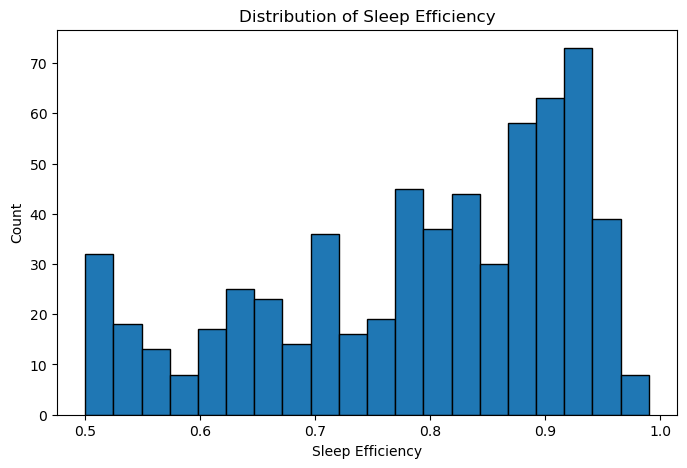

In [5]:
plt.figure(figsize=(8,5))
plt.hist(df['Sleep efficiency'], bins=20, edgecolor='black')
plt.xlabel('Sleep Efficiency')
plt.ylabel('Count')
plt.title('Distribution of Sleep Efficiency')
plt.show()

In [8]:
# low-efficiency cluster
low_eff = df[df['Sleep efficiency'] <= 0.55]
print(low_eff.shape)
print(low_eff[['Age', 'Alcohol consumption', 'Caffeine consumption', 
               'Smoking status', 'Exercise frequency']].describe())

(58, 15)
             Age  Alcohol consumption  Caffeine consumption  \
count  58.000000            55.000000             55.000000   
mean   34.948276             2.454545             21.363636   
std    13.403878             1.751382             24.729173   
min     9.000000             0.000000              0.000000   
25%    27.000000             1.000000              0.000000   
50%    34.000000             2.000000              0.000000   
75%    40.000000             4.000000             50.000000   
max    65.000000             5.000000             75.000000   

       Exercise frequency  
count           57.000000  
mean             1.368421  
std              1.383985  
min              0.000000  
25%              0.000000  
50%              1.000000  
75%              3.000000  
max              5.000000  


In [9]:
# The complement: everyone NOT in the low-efficiency cluster
rest = df[df['Sleep efficiency'] > 0.55]

print("Low-efficiency cluster (n=58):")
print(low_eff[['Age', 'Alcohol consumption', 'Caffeine consumption', 
               'Exercise frequency']].mean())

print("\nRest of dataset (n=560):")
print(rest[['Age', 'Alcohol consumption', 'Caffeine consumption', 
            'Exercise frequency']].mean())

Low-efficiency cluster (n=58):
Age                     34.948276
Alcohol consumption      2.454545
Caffeine consumption    21.363636
Exercise frequency       1.368421
dtype: float64

Rest of dataset (n=560):
Age                     40.903571
Alcohol consumption      0.981550
Caffeine consumption    24.857685
Exercise frequency       1.823105
dtype: float64


In [10]:
from scipy import stats

for col in ['Age', 'Alcohol consumption', 'Caffeine consumption', 'Exercise frequency']:
    low_vals = low_eff[col].dropna()
    rest_vals = rest[col].dropna()
    t_stat, p_val = stats.ttest_ind(low_vals, rest_vals)
    print(f"{col}: low-eff mean={low_vals.mean():.2f}, rest mean={rest_vals.mean():.2f}, p={p_val:.4f}")

Age: low-eff mean=34.95, rest mean=40.90, p=0.0009
Alcohol consumption: low-eff mean=2.45, rest mean=0.98, p=0.0000
Caffeine consumption: low-eff mean=21.36, rest mean=24.86, p=0.4464
Exercise frequency: low-eff mean=1.37, rest mean=1.82, p=0.0203


## Low-Efficiency Cluster Analysis (Sleep Efficiency ≤ 0.55, n=58)

Comparing this subgroup (n=58) against the rest of the dataset (n=560) 
using independent t-tests:

| Feature | Low-Eff Mean | Rest Mean | p-value | Significant? |
|---|---|---|---|---|
| Age | 34.95 | 40.90 | 0.0009 | Yes |
| Alcohol consumption | 2.45 | 0.98 | <0.0001 | Yes (strongest) |
| Exercise frequency | 1.37 | 1.82 | 0.0203 | Yes (weaker) |
| Caffeine consumption | 21.36 | 24.86 | 0.4464 | No |

**Key finding:** Alcohol consumption shows the strongest association 
with the low-efficiency cluster — this group drinks roughly 2.5x more 
on average, and the difference is highly unlikely to be due to chance 
(p<0.0001). The group is also somewhat younger and exercises less, 
though these signals are weaker. Caffeine shows no meaningful 
difference between groups.

**Caveat:** These are correlational comparisons on observational data. 
We cannot conclude alcohol *causes* lower efficiency — other unmeasured 
factors may explain the pattern. This motivates including alcohol as 
a likely important feature in the predictive model, to be confirmed 
via feature importance analysis later.

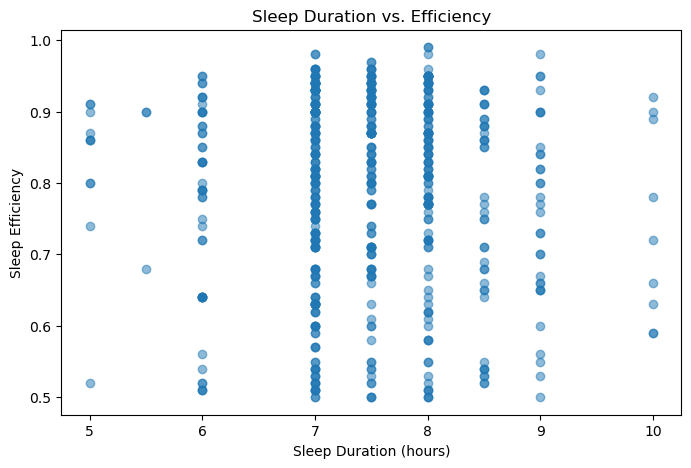

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sleep duration'], df['Sleep efficiency'], alpha=0.5)
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Sleep Efficiency')
plt.title('Sleep Duration vs. Efficiency')
plt.show()

In [11]:
correlation = df['Sleep duration'].corr(df['Sleep efficiency'])
print(f"Correlation: {correlation:.3f}")

Correlation: -0.025


In [12]:
# Group by rounded duration, see mean efficiency per group
df.groupby(df['Sleep duration'].round())['Sleep efficiency'].mean()

Sleep duration
5.0     0.820909
6.0     0.773000
7.0     0.781509
8.0     0.803322
9.0     0.754062
10.0    0.742222
Name: Sleep efficiency, dtype: float64

## Sleep Duration vs. Efficiency

Visual inspection initially suggested a possible pattern where 
efficiency might "cap" around 7-8 hours of sleep duration. Checking 
the correlation coefficient (r = -0.025) showed this isn't the case — 
duration and efficiency have essentially no linear relationship.

Grouping by rounded duration confirms this further:

| Duration (hrs) | Mean Efficiency |
|---|---|
| 5 | 0.821 |
| 6 | 0.773 |
| 7 | 0.782 |
| 8 | 0.803 |
| 9 | 0.754 |
| 10 | 0.742 |

Mean efficiency stays within a narrow band (0.74–0.82) regardless of 
duration, with no consistent upward or downward trend. If anything, 
the longest durations (9-10h) show slightly *lower* mean efficiency, 
but the difference is small and the sample size at 10 hours is 
likely too small to draw a real conclusion from.

**Key finding:** Sleep duration alone is a poor predictor of sleep 
efficiency — neither "more is better" nor a clear plateau effect 
holds in this dataset. This supports focusing on behavioral factors 
(e.g., alcohol consumption, found earlier to be strongly associated 
with low efficiency) rather than duration when building the 
predictive model.

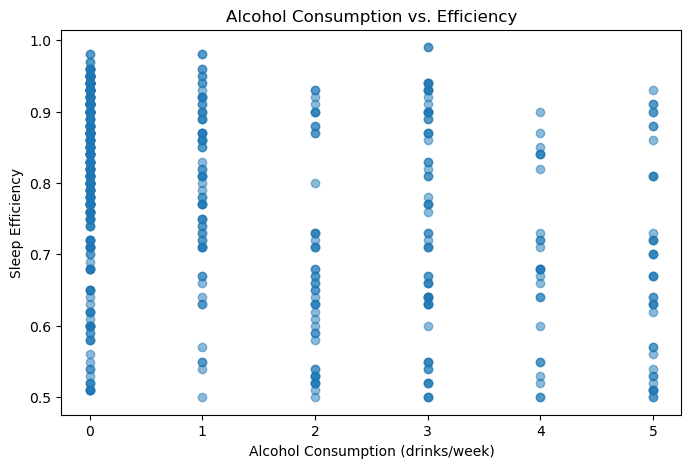

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(df['Alcohol consumption'], df['Sleep efficiency'], alpha=0.5)
plt.xlabel('Alcohol Consumption (drinks/week)')
plt.ylabel('Sleep Efficiency')
plt.title('Alcohol Consumption vs. Efficiency')
plt.show()

In [14]:
df.groupby('Alcohol consumption')['Sleep efficiency'].mean()

Alcohol consumption
0.0    0.831268
1.0    0.801429
2.0    0.682857
3.0    0.749692
4.0    0.689231
5.0    0.681250
Name: Sleep efficiency, dtype: float64

In [15]:
correlation = df['Alcohol consumption'].corr(df['Sleep efficiency'])
print(f"Correlation: {correlation:.3f}")

Correlation: -0.394


## Alcohol Consumption vs. Efficiency

Unlike sleep duration, alcohol consumption shows a real relationship 
with efficiency: correlation r = -0.394 (moderate negative).

Group means confirm a consistent downward trend:

| Alcohol (drinks/week) | Mean Efficiency |
|---|---|
| 0 | 0.831 |
| 1 | 0.801 |
| 2 | 0.683 |
| 3 | 0.750 |
| 4 | 0.689 |
| 5 | 0.681 |

Efficiency drops from ~0.83 at zero drinks to ~0.68 at 4-5 drinks/week 
— a difference of about 0.15, which is substantial on a 0-1 scale. 
The trend isn't perfectly monotonic (a small uptick at 3 drinks), 
likely due to smaller sample sizes at higher consumption levels, but 
the overall downward pattern is clear and consistent with the earlier 
t-test finding (p<0.0001) that alcohol distinguishes the low-efficiency 
cluster from the rest of the dataset.

**Key finding:** Alcohol consumption is the strongest behavioral 
predictor identified so far — both statistically (t-test) and via 
correlation. This will likely be an important feature in the 
predictive model, in contrast to sleep duration, which showed no 
meaningful relationship.